In [1]:
import torch

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [2]:
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
# Load the model
model = build_sam3_image_model()
processor = Sam3Processor(model)

E:\Uni\Bachelorarbeit\sam3\sam3\model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [30]:
#your_path/folder
folder_path = "dataset/mvtec_anomaly_detection/hazelnut/test/print"

ground_truth_path = "dataset/mvtec_anomaly_detection/hazelnut/ground_truth/print"
#.png .jpg .gif etc.
#can be empty string "" if different image types and no non-image files are in the folder
image_type = ".png"

In [ ]:
from PIL import Image
import glob


folder_path = folder_path + "/*" + image_type

image_list = []
image_paths = []
for filename in sorted(glob.glob(folder_path)):
    im = Image.open(filename)
    image_list.append(im)
    image_paths.append(filename)
x = image_paths[0].replace('\\', '/')   
x = x.split('/')
print(x[-2])

000.png


In [5]:
good = 0

for filename in sorted(glob.glob("dataset/mvtec_anomaly_detection/hazelnut/test/good" + "/*" + image_type)):
    im = Image.open(filename)
    good = good + 1
    image_list.append(im)
    image_paths.append(filename)

In [6]:
prompt_list = ["white color"]
prompt = "white color"
confidence_threshold = 0.5

In [7]:
import matplotlib.pyplot as plt

masks = []
single_masks = []
boxes = [] 
scores = []
labels = []
maps = []

for image in image_list:
    inference_state = processor.set_image(image)
    #for prompt in prompt_list:
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_confidence_threshold(state=inference_state, threshold=confidence_threshold)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=prompt)
    #print(inference_state["masks"].shape)
    masks.append(inference_state["masks"])
    if(inference_state["masks"].size(dim=0) > 1):
        scores.append(torch.max(inference_state["scores"], dim=0).values.to(device="cuda"))
        single_masks.append(torch.max(inference_state["masks"].to(torch.float), dim=0).values.to(device="cuda"))
        maps.append(torch.max(inference_state["masks_logits"], dim=0).values.to(device="cuda"))
        labels.append(torch.tensor(1, dtype=int).to(device="cuda"))
        
    elif (inference_state["masks"].size(dim=0) == 1):
        scores.append((inference_state["scores"]).squeeze(0))
        single_masks.append(inference_state["masks"].squeeze(0))
        maps.append(inference_state["masks_logits"].squeeze(0))
        labels.append(torch.tensor(1, dtype=int).to(device="cuda"))
        
    else:
        scores.append(torch.tensor(0, dtype=float).to(device="cuda"))
        single_masks.append(torch.zeros(1,1024,1024).to(device="cuda"))
        maps.append(torch.zeros(1,1024,1024).to(device="cuda"))
        labels.append(torch.tensor(0, dtype=int).to(device="cuda"))
    boxes.append(inference_state["boxes"])
    
    

    

In [8]:
ground_truth_path = ground_truth_path + "/*" + image_type

gt_mask_list = []
gt_mask_paths = []
for filename in sorted(glob.glob(ground_truth_path)):
    im = Image.open(filename)
    gt_mask_list.append(im)
    gt_mask_paths.append(filename)


torch.Size([1024, 1024])


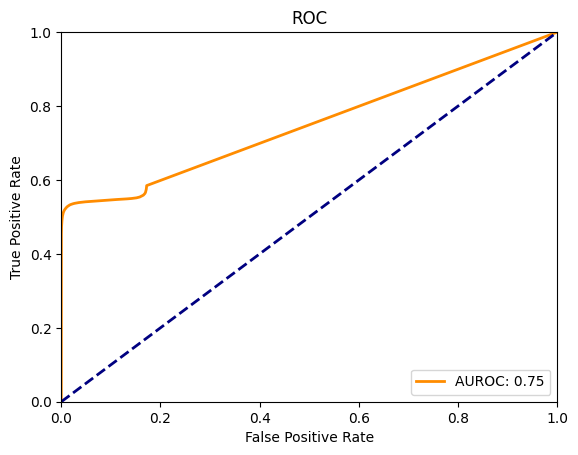

image AUROC:
tensor(0.7941, device='cuda:0')
pixel AUROC:
tensor(0.7495, device='cuda:0')
tensor(0.4176, device='cuda:0')
tensor(0.2764, device='cuda:0')


In [9]:
from anomalib.metrics import AUROC, PRO, AUPRO
from anomalib.data.dataclasses.torch import ImageBatch
from torchvision import transforms
transform = transforms.ToTensor()
pixel_auroc = AUROC(fields=["anomaly_map", "gt_mask"], prefix="pixel")
image_auroc = AUROC(fields=["pred_score", "gt_label"], prefix="image")
images_as_tensors = []

for image in image_list:
    images_as_tensors.append(transform(image).to(device="cuda"))

gt_masks_as_tensors = []

for image in gt_mask_list:
    gt_masks_as_tensors.append(transform(image).squeeze(0).to(device="cuda"))
    
good_as_tensors = []    
    
for i in range(good):
    gt_mask_paths.append("")
    #images_as_tensors.append(transform(image))
    gt_masks_as_tensors.append(torch.zeros(inference_state["original_height"], inference_state["original_width"], dtype=int).to(device="cuda"))
    
images_tensor = torch.stack(images_as_tensors).to(device="cuda")
#print(gt_masks_as_tensors[0])

gt_masks_tensor = torch.stack(gt_masks_as_tensors).to(device="cuda")
print(gt_masks_tensor[0].shape)

gt_labels = torch.ones(len(image_list)-good, dtype=int).to(device="cuda")

gt_labels = torch.cat([gt_labels, torch.zeros(good, dtype=int).to(device="cuda")], dim=0).to(device="cuda")

batch = ImageBatch(
    image=images_tensor,
    gt_label=gt_labels,
    image_path=image_paths,
    pred_label=torch.stack(labels, dim=0).to(device="cuda"),
    pred_mask=torch.stack(single_masks, dim=0).to(device="cuda"),
    pred_score=torch.stack(scores, dim=0).to(device="cuda"),
    gt_mask=gt_masks_tensor,
    mask_path=gt_mask_paths,
    anomaly_map=torch.stack(maps, dim=0).to(device="cuda")
)



image_auroc.update(batch)
pixel_auroc.update(batch)
    
fig, str = pixel_auroc.generate_figure()    

plt.show()
    
print("image AUROC:")
print(image_auroc.compute())
print("pixel AUROC:")
print(pixel_auroc.compute())

pro = PRO(fields=["anomaly_map", "gt_mask"])
aupro = AUPRO(fields=["anomaly_map", "gt_mask"])

pro.update(batch)
aupro.update(batch)

print(aupro.compute())
print(pro.compute())